In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from itertools import product
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

np.random.seed(7)
tf.random.set_seed(7)
plt.rcParams['figure.figsize'] = [13, 5]
plt.rcParams['font.size'] = 11
print('ready')

ready


Data Exploration and Visualization



In [2]:
# load and sort the csv
prices = pd.read_csv('oil_prices_2426.csv', encoding='utf-8-sig')
prices.columns = ['date', 'usd']
prices['date'] = pd.to_datetime(prices['date'], dayfirst=True)
prices = prices.sort_values('date').reset_index(drop=True)
prices.set_index('date', inplace=True)

print('rows:', len(prices))
print('range:', prices.index[0].date(), '->', prices.index[-1].date())
print('missing:', prices.isnull().sum().values[0])
print()
print(prices.describe().round(2))

rows: 500
range: 2024-09-21 -> 2026-02-02
missing: 0

          usd
count  500.00
mean    75.87
std     42.91
min     16.48
25%     35.37
50%     64.29
75%    111.57
max    158.78


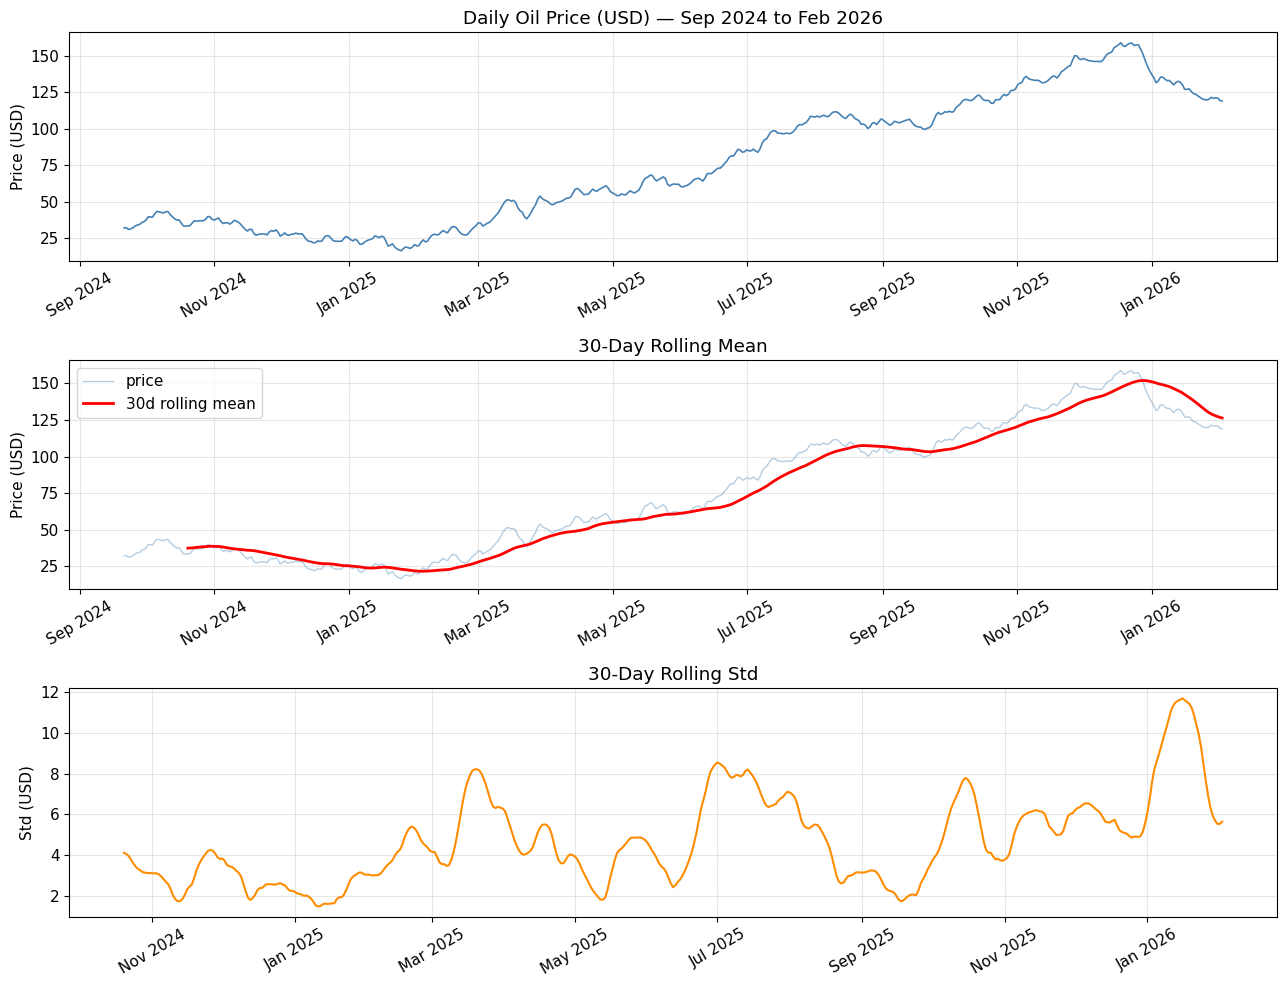

In [3]:
# rolling stats to check if mean and variance over time
roll_mean = prices['usd'].rolling(30).mean()
roll_std  = prices['usd'].rolling(30).std()

fig, axes = plt.subplots(3, 1, figsize=(13, 10))

axes[0].plot(prices.index, prices['usd'], color='steelblue', lw=1.2)
axes[0].set_title('Daily Oil Price (USD) — Sep 2024 to Feb 2026')
axes[0].set_ylabel('Price (USD)')

# rising rolling mean = non-stationary trend
axes[1].plot(prices.index, prices['usd'], color='steelblue', alpha=0.4, lw=1, label='price')
axes[1].plot(prices.index, roll_mean, color='red', lw=2, label='30d rolling mean')
axes[1].set_title('30-Day Rolling Mean')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

# increasing spread = non-constant variance
axes[2].plot(prices.index, roll_std, color='darkorange', lw=1.5)
axes[2].set_title('30-Day Rolling Std')
axes[2].set_ylabel('Std (USD)')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_eda.png', dpi=150, bbox_inches='tight')
plt.show()

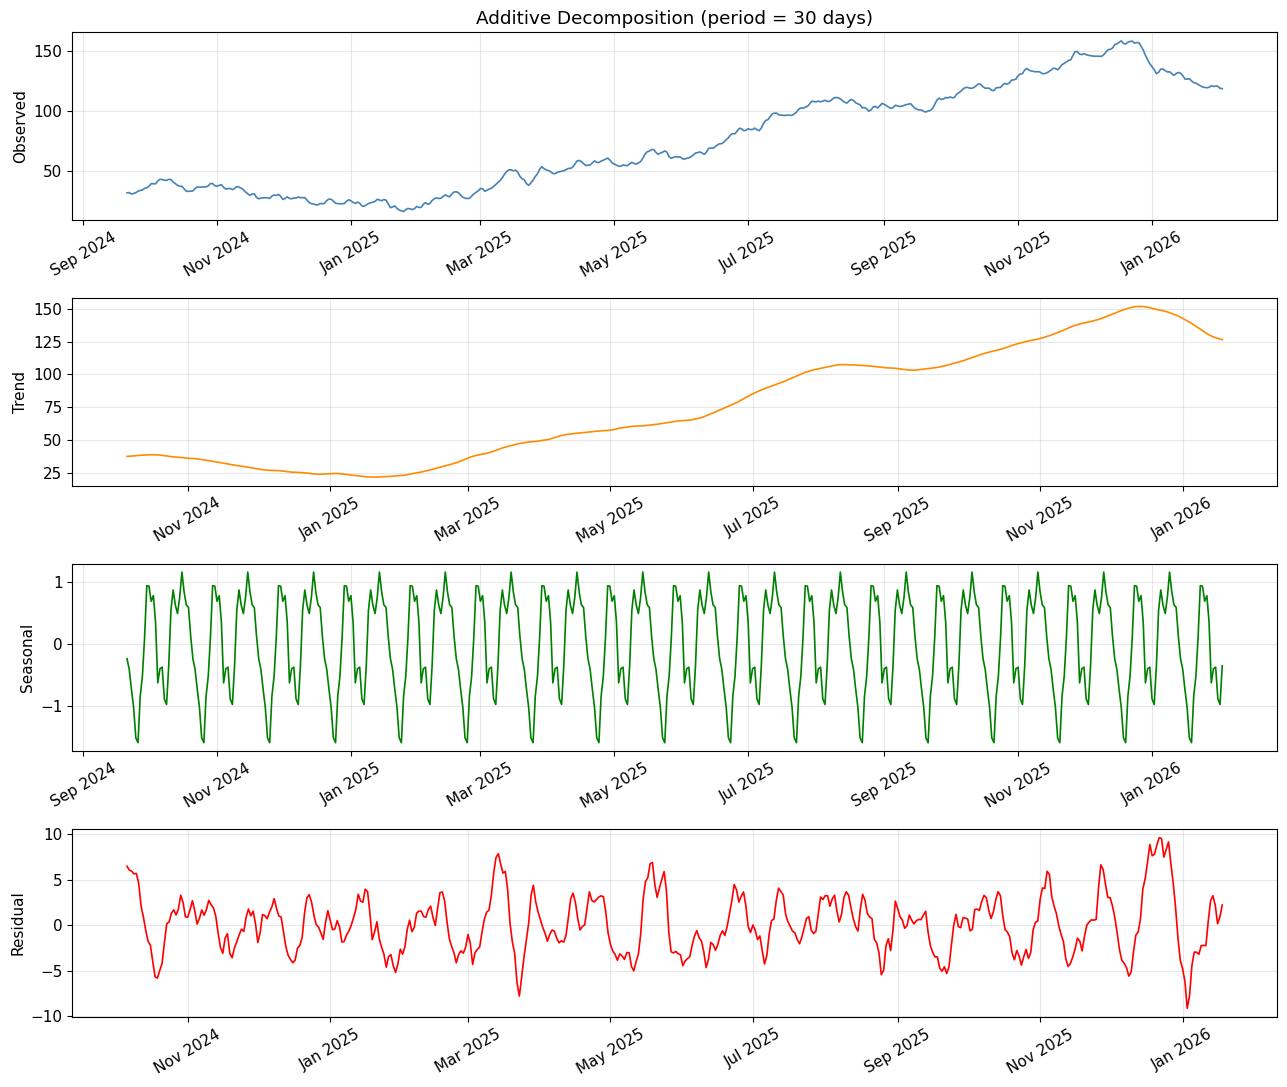

In [4]:
decomp = seasonal_decompose(prices['usd'], model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(13, 11))
parts = [('Observed', decomp.observed, 'steelblue'),
         ('Trend',    decomp.trend,    'darkorange'),
         ('Seasonal', decomp.seasonal, 'green'),
         ('Residual', decomp.resid,    'red')]

for ax, (label, vals, col) in zip(axes, parts):
    ax.plot(prices.index, vals, color=col, lw=1.2)
    ax.set_ylabel(label)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3)

axes[0].set_title('Additive Decomposition (period = 30 days)')
plt.tight_layout()
plt.savefig('fig2_decomp.png', dpi=150, bbox_inches='tight')
plt.show()

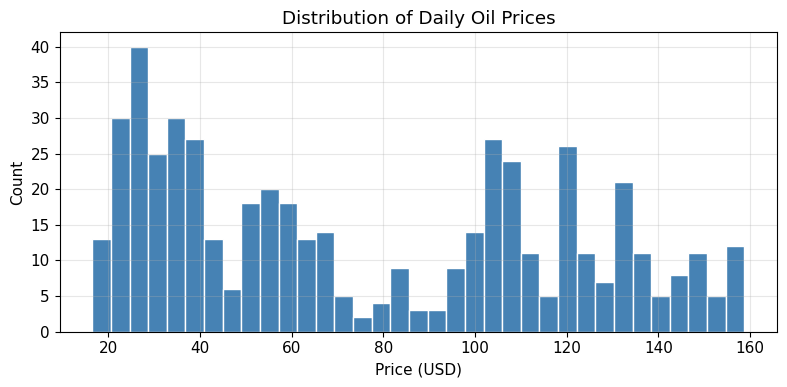

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prices['usd'], bins=35, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Daily Oil Prices')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Count')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_price_hist.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 1 — Stationarity Testing

--- Raw oil price ---
ADF  stat=-0.5462  p=0.8827  -> NON-STATIONARY
KPSS stat=3.7056   p=0.0100  -> NON-STATIONARY



/tmp/ipykernel_930/584038494.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  k = kpss(series.dropna(), regression='c', nlags='auto')


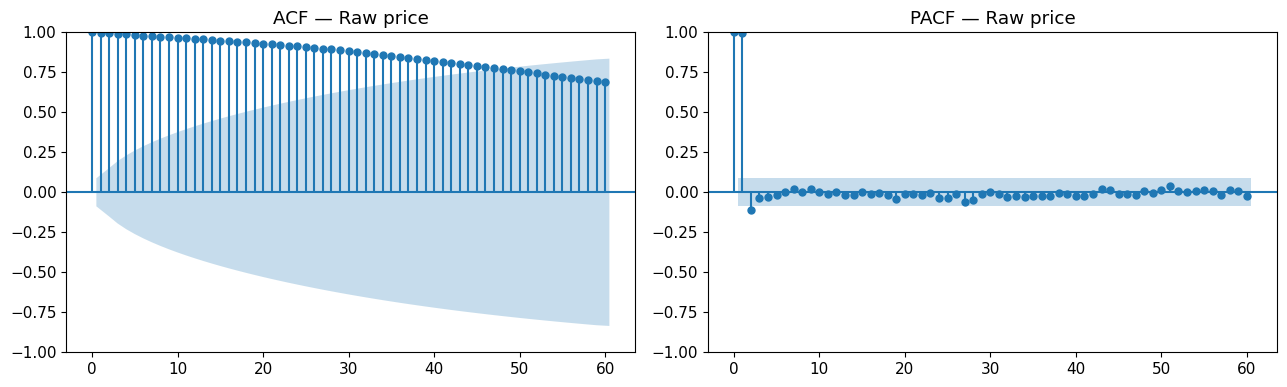

In [6]:
def check_stationarity(series, label):
    print(f'--- {label} ---')
    adf = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF  stat={adf[0]:.4f}  p={adf[1]:.4f}  -> {"stationary" if adf[1]<0.05 else "NON-STATIONARY"}')
    k = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS stat={k[0]:.4f}   p={k[1]:.4f}  -> {"NON-STATIONARY" if k[1]<0.05 else "stationary"}')
    print()
    return adf[1], k[1]


def show_acf_pacf(series, lags, title):
    clean = series.dropna()
    safe  = min(lags, len(clean)//2 - 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    plot_acf(clean,  lags=safe, ax=axes[0])
    plot_pacf(clean, lags=safe, ax=axes[1], method='ywm')
    axes[0].set_title(f'ACF — {title}')
    axes[1].set_title(f'PACF — {title}')
    plt.tight_layout()
    plt.show()


# slow ACF decay and high p-value both confirm raw series is non-stationary
check_stationarity(prices['usd'], 'Raw oil price')
show_acf_pacf(prices['usd'], lags=60, title='Raw price')

--- First differenced (d=1) ---
ADF  stat=-4.5415  p=0.0002  -> stationary
KPSS stat=0.1903   p=0.1000  -> stationary



/tmp/ipykernel_930/584038494.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  k = kpss(series.dropna(), regression='c', nlags='auto')


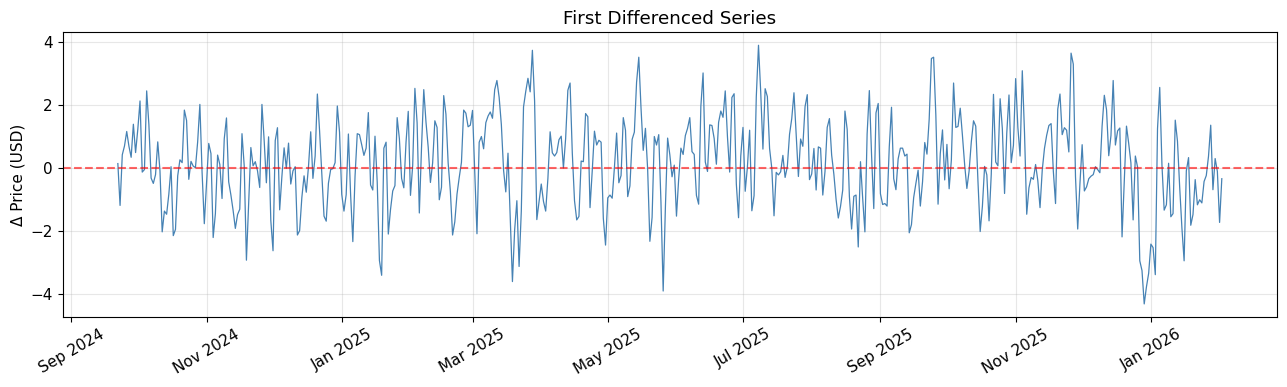

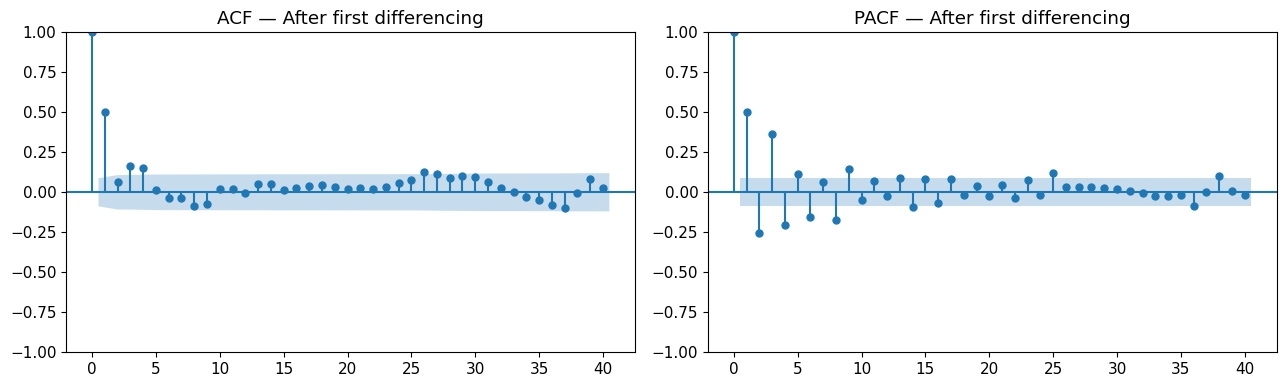

In [7]:
# first difference removes the trend - check if it achieves stationarity
diff1 = prices['usd'].diff().dropna()
check_stationarity(diff1, 'First differenced (d=1)')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(diff1, color='steelblue', lw=0.9)
ax.axhline(0, color='red', ls='--', alpha=0.6)
ax.set_title('First Differenced Series')
ax.set_ylabel('Δ Price (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_diff1.png', dpi=150, bbox_inches='tight')
plt.show()

show_acf_pacf(diff1, lags=40, title='After first differencing')

ARIMA Model Selection (Grid Search)

In [8]:
import warnings as _w
from statsmodels.tools.sm_exceptions import ConvergenceWarning

def search_arima(series, p_vals, d_vals, q_vals):
    rows   = []
    combos = list(product(p_vals, d_vals, q_vals))
    print(f'testing {len(combos)} combinations...')
    for i, (p, d, q) in enumerate(combos):
        try:
            # suppress frequency inference + convergence warnings during grid search
            with _w.catch_warnings():
                _w.simplefilter('ignore')
                m = ARIMA(series, order=(p, d, q)).fit()
            rows.append({'p':p, 'd':d, 'q':q, 'AIC':round(m.aic,2), 'BIC':round(m.bic,2)})
        except Exception:
            pass
        if (i+1) % 60 == 0:
            print(f'  {i+1}/{len(combos)} done')
    tbl = pd.DataFrame(rows).sort_values('AIC').reset_index(drop=True)
    return tbl


aic_tbl = search_arima(prices['usd'], range(0,9), range(0,3), range(0,9))
print()
print('Top 10 by AIC:')
print(aic_tbl.head(10).to_string(index=False))

testing 243 combinations...
  60/243 done
  120/243 done
  180/243 done
  240/243 done

Top 10 by AIC:
 p  d  q     AIC     BIC
 2  2  7 1429.36 1471.46
 4  1  5 1429.77 1471.90
 0  1  5 1429.90 1455.17
 1  1  4 1430.46 1455.73
 2  1  4 1430.85 1460.34
 5  1  5 1430.95 1477.29
 4  1  1 1431.11 1456.39
 4  1  8 1431.19 1485.96
 0  1  6 1431.36 1460.84
 3  1  3 1431.69 1461.18


In [9]:
best_row   = aic_tbl[aic_tbl['d'] == 1].iloc[0]
best_order = (int(best_row['p']), 1, int(best_row['q']))
print(f'selected: ARIMA{best_order}  AIC={best_row["AIC"]}')

selected: ARIMA(4, 1, 5)  AIC=1429.77


In [10]:
fitted_arima = ARIMA(prices['usd'], order=best_order).fit()
print(fitted_arima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                    usd   No. Observations:                  500
Model:                 ARIMA(4, 1, 5)   Log Likelihood                -704.886
Date:                Tue, 10 Mar 2026   AIC                           1429.772
Time:                        08:53:01   BIC                           1471.898
Sample:                    09-21-2024   HQIC                          1446.304
                         - 02-02-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6070      0.155      3.921      0.000       0.304       0.910
ar.L2         -0.7839      0.073    -10.671      0.000      -0.928      -0.640
ar.L3          0.8038      0.084      9.562      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


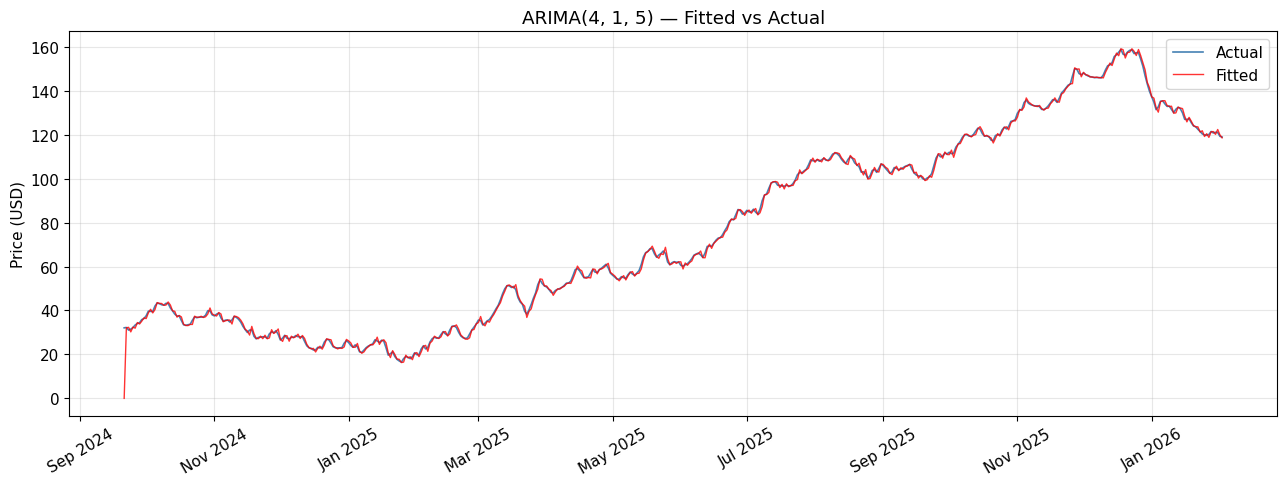

In [11]:
in_sample = fitted_arima.fittedvalues

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(prices.index, prices['usd'], color='steelblue', lw=1.2, label='Actual')
ax.plot(prices.index, in_sample,    color='red',       lw=1,   alpha=0.8, label='Fitted')
ax.set_title(f'ARIMA{best_order} — Fitted vs Actual')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_arima_fitted.png', dpi=150, bbox_inches='tight')
plt.show()

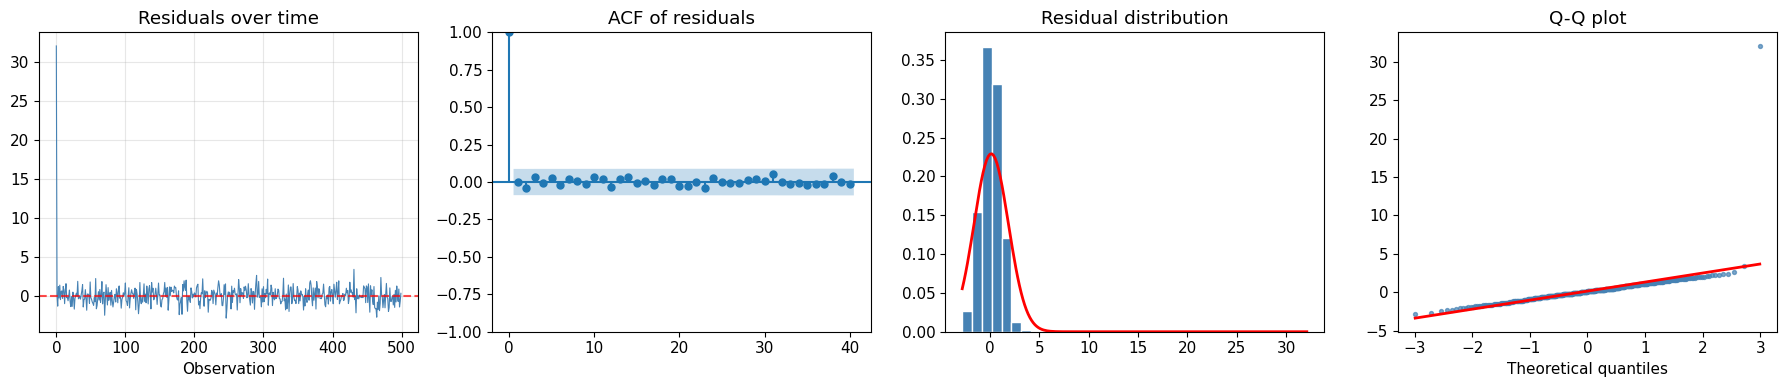

mean=0.1395  std=1.7409

Ljung-Box:
     lb_stat  lb_pvalue
10  2.801261   0.985722
20  5.208981   0.999619
30  7.065958   0.999995


In [12]:
resids = fitted_arima.resid.dropna()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# should hover around zero with no pattern
axes[0].plot(resids.values, color='steelblue', lw=0.8)
axes[0].axhline(0, color='red', ls='--', alpha=0.7)
axes[0].set_title('Residuals over time')
axes[0].set_xlabel('Observation')
axes[0].grid(alpha=0.3)

# no significant spikes = model has captured the autocorrelation
plot_acf(resids, lags=40, ax=axes[1])
axes[1].set_title('ACF of residuals')

# residuals should be roughly normal
mu, sd = resids.mean(), resids.std()
axes[2].hist(resids, bins=35, color='steelblue', edgecolor='white', density=True)
xr = np.linspace(resids.min(), resids.max(), 200)
axes[2].plot(xr, (1/(sd*np.sqrt(2*np.pi)))*np.exp(-0.5*((xr-mu)/sd)**2), color='red', lw=2)
axes[2].set_title('Residual distribution')

(osm, osr), (slope, intercept, _) = stats.probplot(resids, dist='norm')
axes[3].scatter(osm, osr, color='steelblue', s=8, alpha=0.7)
axes[3].plot(osm, slope*np.array(osm)+intercept, color='red', lw=2)
axes[3].set_title('Q-Q plot')
axes[3].set_xlabel('Theoretical quantiles')

plt.tight_layout()
plt.savefig('fig6_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'mean={resids.mean():.4f}  std={resids.std():.4f}')

lb = acorr_ljungbox(resids, lags=[10, 20, 30], return_df=True)
print('\nLjung-Box:')
print(lb)

Out-of-Sample Evaluation

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(4, 1, 5) test metrics:
{'RMSE': np.float64(18.3614), 'MAE': np.float64(14.8621), 'MAPE%': np.float64(10.24)}


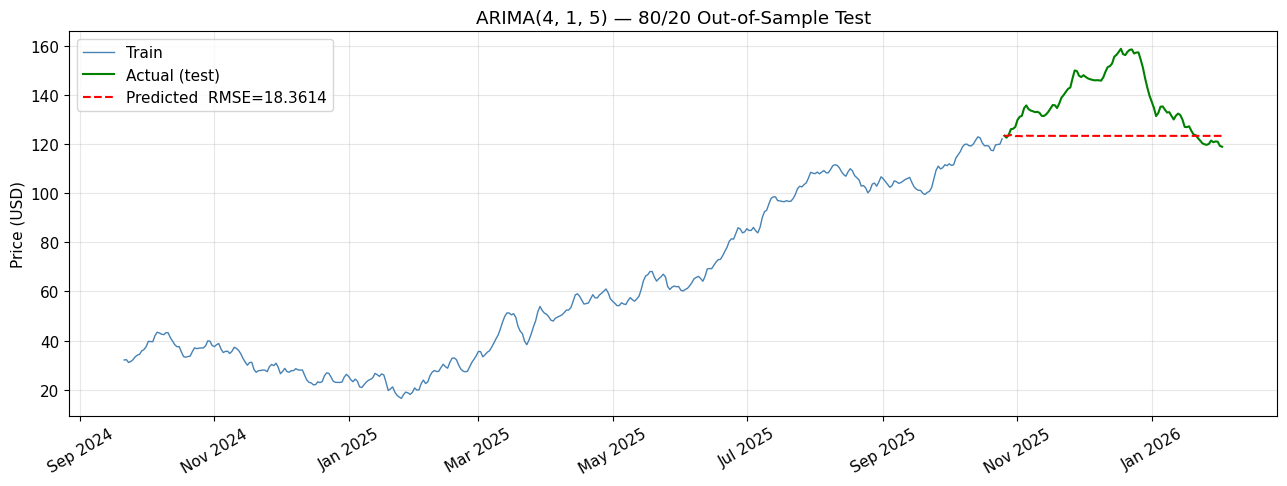

In [13]:
def get_metrics(actual, predicted):
    a = np.array(actual)
    p = np.array(predicted)
    rmse = np.sqrt(mean_squared_error(a, p))
    mae  = np.mean(np.abs(a - p))
    mape = np.mean(np.abs((a - p) / a)) * 100
    return {'RMSE': round(rmse,4), 'MAE': round(mae,4), 'MAPE%': round(mape,2)}


# 80/20 split
split      = int(len(prices) * 0.8)
tr         = prices['usd'].iloc[:split]
te         = prices['usd'].iloc[split:]

arima_tr   = ARIMA(tr, order=best_order).fit()
fc_te      = arima_tr.get_forecast(steps=len(te)).predicted_mean
fc_te.index = te.index

arima_scores = get_metrics(te, fc_te)
print(f'ARIMA{best_order} test metrics:')
print(arima_scores)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(tr.index, tr.values, color='steelblue', lw=1,   label='Train')
ax.plot(te.index, te.values, color='green',     lw=1.5, label='Actual (test)')
ax.plot(te.index, fc_te,     color='red', ls='--', lw=1.5,
        label=f'Predicted  RMSE={arima_scores["RMSE"]}')
ax.set_title(f'ARIMA{best_order} — 80/20 Out-of-Sample Test')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig7_arima_test.png', dpi=150, bbox_inches='tight')
plt.show()

## Part 1 — ARIMA 24-Month Forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


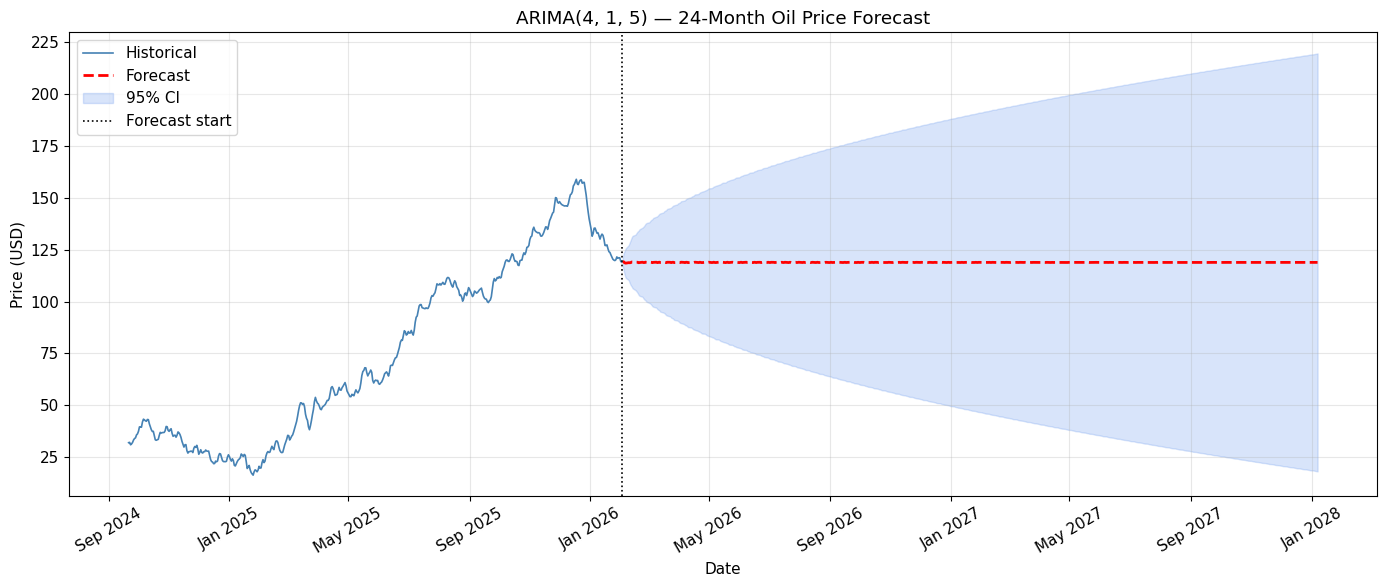

forecast: 2026-02-03 -> 2028-01-07
price at month 24: $118.81


In [14]:
def plot_forecast(series, fc_mean, lower, upper, title, fname):
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(series.index, series.values, color='steelblue', lw=1.2, label='Historical')
    ax.plot(fc_mean.index, fc_mean.values, color='red', ls='--', lw=2, label='Forecast')
    ax.fill_between(fc_mean.index, lower, upper,
                    color='cornflowerblue', alpha=0.25, label='95% CI')
    ax.axvline(series.index[-1], color='black', ls=':', lw=1.2, label='Forecast start')
    ax.set_title(title)
    ax.set_ylabel('Price (USD)')
    ax.set_xlabel('Date')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


# refit on full data for final forecast
final_arima = ARIMA(prices['usd'], order=best_order).fit()

n_steps    = 504   # ~24 months of trading days
fc_obj     = final_arima.get_forecast(steps=n_steps)
fc_mean    = fc_obj.predicted_mean
ci         = fc_obj.conf_int(alpha=0.05)

last_date  = prices.index[-1]
future_idx = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=n_steps)
fc_mean.index = future_idx
ci.index      = future_idx

plot_forecast(prices['usd'], fc_mean, ci.iloc[:,0], ci.iloc[:,1],
              f'ARIMA{best_order} — 24-Month Oil Price Forecast',
              'fig8_arima_forecast.png')

print(f'forecast: {future_idx[0].date()} -> {future_idx[-1].date()}')
print(f'price at month 24: ${fc_mean.iloc[-1]:.2f}')

## Part 2 — LSTM Alternative Model

In [15]:
# scale prices to [0,1] - LSTMs are sensitive to input magnitude
scaler    = MinMaxScaler()
raw_vals  = prices['usd'].values.reshape(-1, 1)
scaled    = scaler.fit_transform(raw_vals).flatten()


def make_sequences(arr, win):
    X, y = [], []
    for i in range(len(arr) - win):
        X.append(arr[i : i+win])
        y.append(arr[i+win])
    return np.array(X)[..., np.newaxis], np.array(y)


split_n      = int(len(scaled) * 0.8)
train_scaled = scaled[:split_n]
test_scaled  = scaled[split_n:]
print(f'train: {split_n} days  test: {len(scaled)-split_n} days')

train: 400 days  test: 100 days


In [16]:
tuning_results = []

for win in [15, 20, 30]:
    for units in [32, 50, 64]:
        X_tr, y_tr = make_sequences(train_scaled, win)

        m = Sequential([
            LSTM(units, return_sequences=True, input_shape=(win, 1)),
            Dropout(0.3),
            LSTM(units//2),
            Dropout(0.3),
            Dense(1)
        ])
        m.compile(optimizer=Adam(0.001), loss='mse')

        h = m.fit(X_tr, y_tr, epochs=30, batch_size=16,
                  validation_split=0.1, verbose=0,
                  callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])

        best_val = min(h.history['val_loss'])
        tuning_results.append({'window':win, 'units':units, 'val_loss':round(best_val,6)})
        print(f'win={win}  units={units}  val_loss={best_val:.6f}')

tuning_df  = pd.DataFrame(tuning_results).sort_values('val_loss')
best_win   = int(tuning_df.iloc[0]['window'])
best_units = int(tuning_df.iloc[0]['units'])
print(f'\nbest: window={best_win}  units={best_units}')
print(tuning_df.to_string(index=False))

win=15  units=32  val_loss=0.000830
win=15  units=50  val_loss=0.000927
win=15  units=64  val_loss=0.000849
win=20  units=32  val_loss=0.000841
win=20  units=50  val_loss=0.000714
win=20  units=64  val_loss=0.000642
win=30  units=32  val_loss=0.001180
win=30  units=50  val_loss=0.000701
win=30  units=64  val_loss=0.000810

best: window=20  units=64
 window  units  val_loss
     20     64  0.000642
     30     50  0.000701
     20     50  0.000714
     30     64  0.000810
     15     32  0.000830
     20     32  0.000841
     15     64  0.000849
     15     50  0.000927
     30     32  0.001180


In [17]:
def build_network(win, units):
    m = Sequential([
        LSTM(units, return_sequences=True, input_shape=(win, 1)),
        Dropout(0.3),
        LSTM(units//2),
        Dropout(0.3),
        Dense(1)
    ])
    m.compile(optimizer=Adam(0.001), loss='mse')
    return m


X_tr, y_tr = make_sequences(train_scaled, best_win)
X_te, y_te = make_sequences(scaled,       best_win)

lstm_model = build_network(best_win, best_units)
lstm_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, verbose=1),
    ModelCheckpoint('best_lstm.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

history = lstm_model.fit(
    X_tr, y_tr,
    epochs           = 100,
    batch_size       = 16,
    validation_split = 0.1,
    callbacks        = callbacks,
    verbose          = 1
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0660 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0060 - val_loss: 9.6354e-04 - learning_rate: 0.0010
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0032 - val_loss: 9.1242e-04 - learning_rate: 0.0010
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0041 - val_loss: 9.3439e-04 - learning_rate: 0.0010
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0036 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0034 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0029 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0027 - val_loss: 9.6415e-04 - learning_rate: 0.0010
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0028 - val_loss: 8.1550e-04 - learning_rat

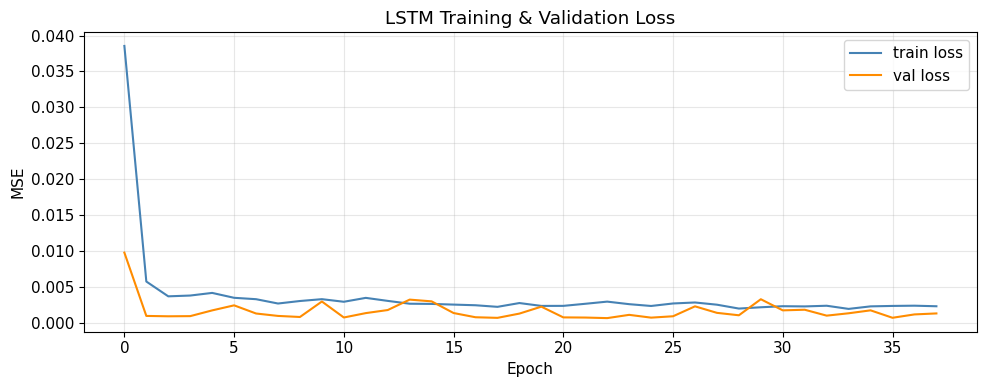

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     color='steelblue',  lw=1.5, label='train loss')
ax.plot(history.history['val_loss'], color='darkorange', lw=1.5, label='val loss')
ax.set_title('LSTM Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig9_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
LSTM test metrics:
{'RMSE': np.float64(6.6678), 'MAE': np.float64(5.8181), 'MAPE%': np.float64(4.12)}
test_dates=80  test_actual=80  test_preds=80


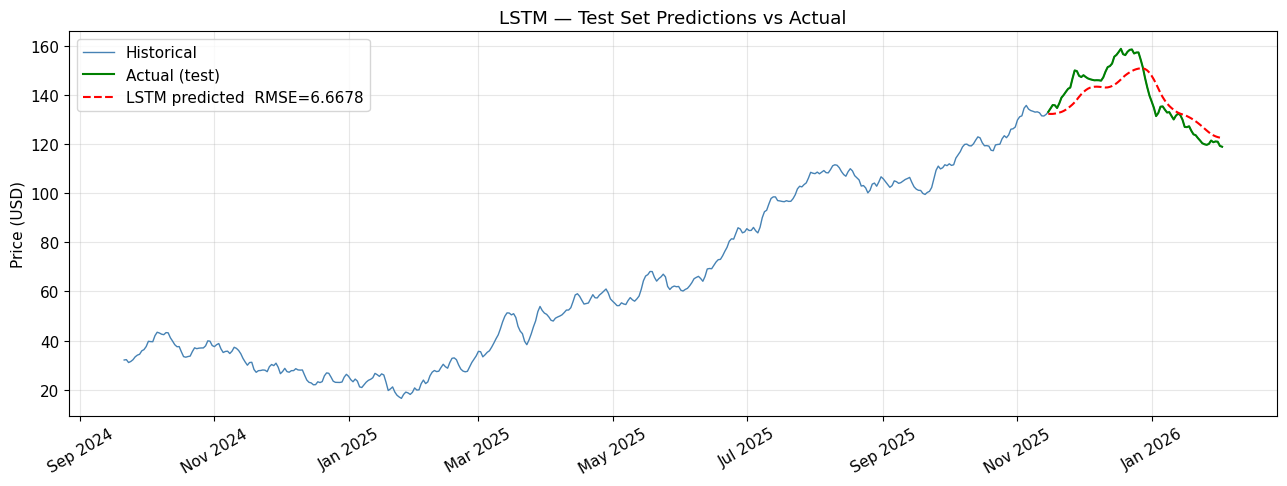

In [20]:
n_test        = len(test_scaled) - best_win   # number of test predictions
test_preds_sc = lstm_model.predict(X_te[-n_test:])
test_preds    = scaler.inverse_transform(test_preds_sc).flatten()
test_actual   = scaler.inverse_transform(y_te[-n_test:].reshape(-1,1)).flatten()

lstm_scores = get_metrics(test_actual, test_preds)
print('LSTM test metrics:')
print(lstm_scores)

test_dates = prices.index[split_n + best_win:]
print(f'test_dates={len(test_dates)}  test_actual={len(test_actual)}  test_preds={len(test_preds)}')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(prices.index, prices['usd'], color='steelblue', lw=1,   label='Historical')
ax.plot(test_dates,   test_actual,   color='green',     lw=1.5, label='Actual (test)')
ax.plot(test_dates,   test_preds,    color='red', ls='--', lw=1.5,
        label=f'LSTM predicted  RMSE={lstm_scores["RMSE"]}')
ax.set_title('LSTM — Test Set Predictions vs Actual')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig10_lstm_test.png', dpi=150, bbox_inches='tight')
plt.show()

LSTM 24-Month Forecast with Monte Carlo Dropout

running Monte Carlo dropout forecast (30 simulations)...


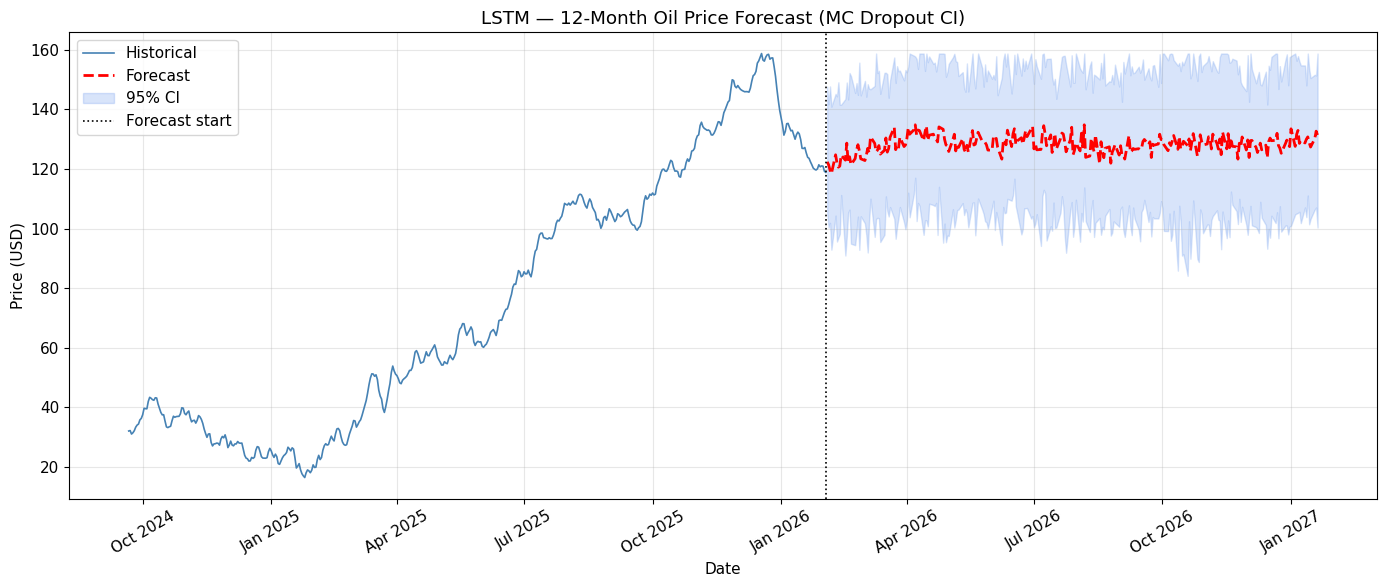

forecast: 2026-02-03 -> 2027-01-20
price at month 12: $131.37


In [22]:
@tf.function
def single_run(model, x):
    return model(x, training=True)

def mc_forecast(model, seed_window, n_steps, n_runs=30):
    sims = []
    for _ in range(n_runs):
        seq   = list(seed_window.copy())
        preds = []
        for _ in range(n_steps):
            x_in = np.array(seq[-best_win:]).reshape(1, best_win, 1)
            p    = float(single_run(model, x_in))
            p    = np.clip(p, 0.0, 1.0)
            preds.append(p)
            seq.append(p)
        sims.append(preds)
    sims = np.array(sims)
    return sims.mean(axis=0), np.percentile(sims, 2.5, axis=0), np.percentile(sims, 97.5, axis=0)


print('running Monte Carlo dropout forecast (30 simulations)...')
seed_seq = scaled[-best_win:]

mean_sc, lo_sc, hi_sc = mc_forecast(lstm_model, seed_seq, n_steps=252, n_runs=30)

# invert scaling back to USD
lstm_fc_mean  = scaler.inverse_transform(mean_sc.reshape(-1,1)).flatten()
lstm_fc_lower = scaler.inverse_transform(lo_sc.reshape(-1,1)).flatten()
lstm_fc_upper = scaler.inverse_transform(hi_sc.reshape(-1,1)).flatten()

last_date   = prices.index[-1]
future_idx  = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=252)
fc_lstm_ser = pd.Series(lstm_fc_mean, index=future_idx)

plot_forecast(prices['usd'], fc_lstm_ser, lstm_fc_lower, lstm_fc_upper,
              'LSTM — 12-Month Oil Price Forecast (MC Dropout CI)',
              'fig11_lstm_forecast.png')

print(f'forecast: {future_idx[0].date()} -> {future_idx[-1].date()}')
print(f'price at month 12: ${lstm_fc_mean[-1]:.2f}')

Model Comparison - ARIMA vs LSTM



In [23]:
print('=' * 55)
print('MODEL COMPARISON (same 80/20 holdout)')
print('=' * 55)
print(f'{"Metric":<25} {"ARIMA":>12} {"LSTM":>12}')
print('-' * 55)
for k in arima_scores:
    print(f'{k:<25} {arima_scores[k]:>12} {lstm_scores[k]:>12}')
print('-' * 55)
print(f'{"Stationarity needed":<25} {"Yes":>12} {"No":>12}')
print(f'{"Confidence intervals":<25} {"Analytical":>12} {"MC Dropout":>12}')
print(f'{"Interpretability":<25} {"High":>12} {"Low":>12}')

MODEL COMPARISON (same 80/20 holdout)
Metric                           ARIMA         LSTM
-------------------------------------------------------
RMSE                           18.3614       6.6678
MAE                            14.8621       5.8181
MAPE%                            10.24         4.12
-------------------------------------------------------
Stationarity needed                Yes           No
Confidence intervals        Analytical   MC Dropout
Interpretability                  High          Low


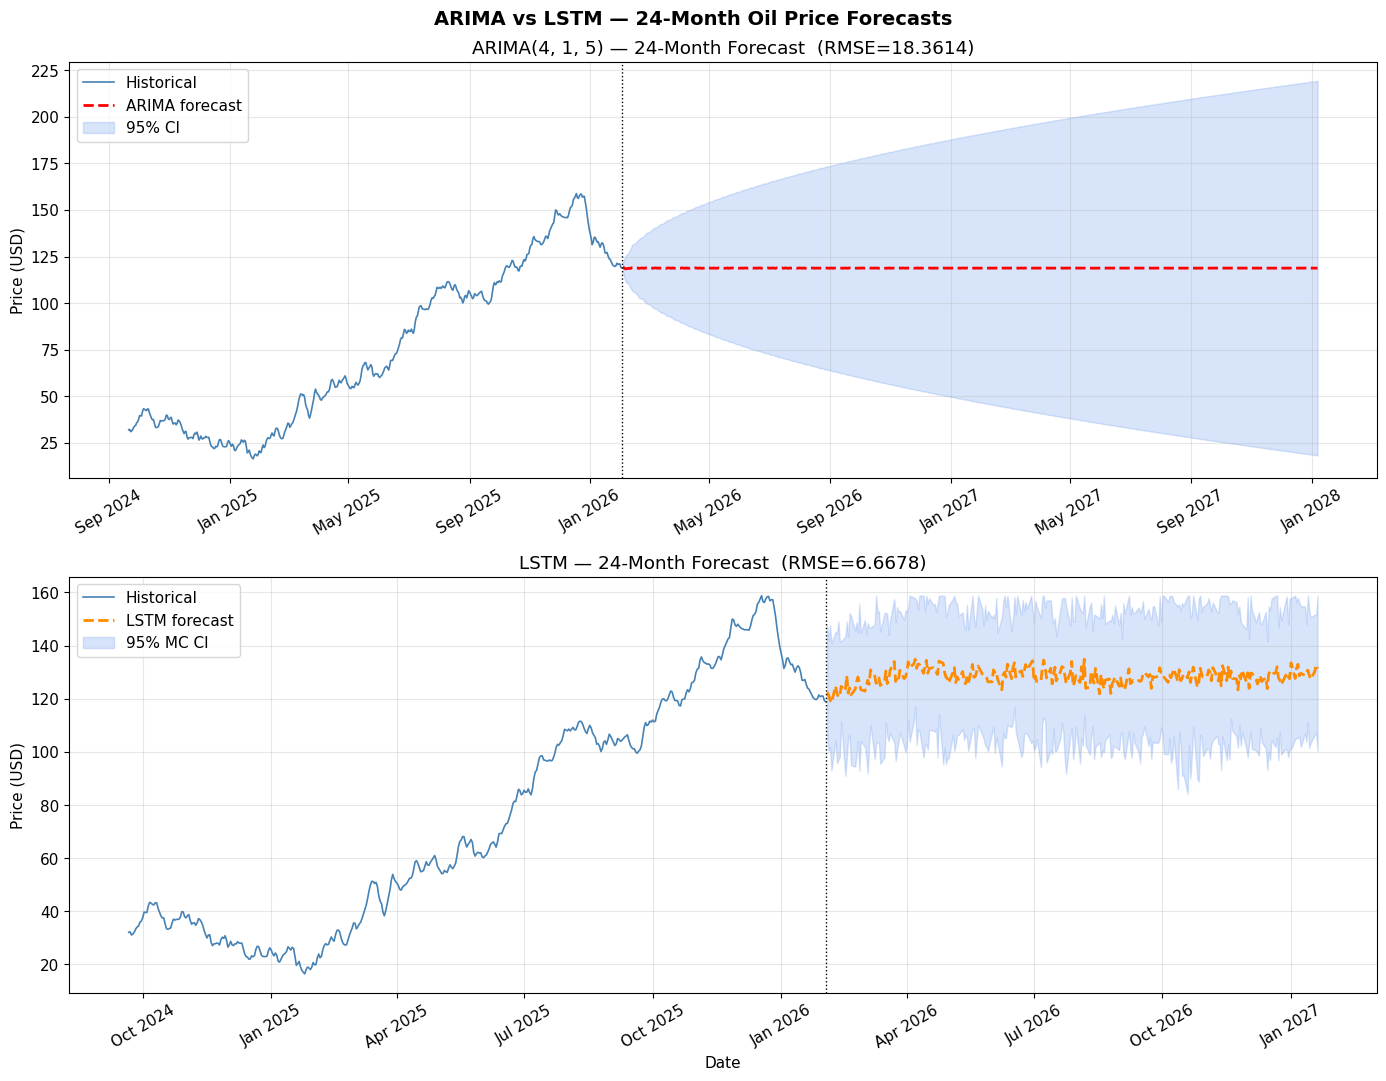

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# ARIMA forecast
axes[0].plot(prices.index, prices['usd'], color='steelblue', lw=1.2, label='Historical')
axes[0].plot(fc_mean.index, fc_mean.values, color='red', ls='--', lw=2, label='ARIMA forecast')
axes[0].fill_between(fc_mean.index, ci.iloc[:,0], ci.iloc[:,1],
                     color='cornflowerblue', alpha=0.25, label='95% CI')
axes[0].axvline(prices.index[-1], color='black', ls=':', lw=1)
axes[0].set_title(f'ARIMA{best_order} — 24-Month Forecast  (RMSE={arima_scores["RMSE"]})')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(alpha=0.3)

# LSTM forecast
axes[1].plot(prices.index, prices['usd'], color='steelblue', lw=1.2, label='Historical')
axes[1].plot(future_idx, lstm_fc_mean, color='darkorange', ls='--', lw=2, label='LSTM forecast')
axes[1].fill_between(future_idx, lstm_fc_lower, lstm_fc_upper,
                     color='cornflowerblue', alpha=0.25, label='95% MC CI')
axes[1].axvline(prices.index[-1], color='black', ls=':', lw=1)
axes[1].set_title(f'LSTM — 24-Month Forecast  (RMSE={lstm_scores["RMSE"]})')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(alpha=0.3)

plt.suptitle('ARIMA vs LSTM — 24-Month Oil Price Forecasts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Forecast vs Real World (Post Feb 2026)

Forecast vs Actual (post dataset):
Date                Actual      ARIMA       LSTM
------------------------------------------------
2026-02-03          120.10     119.24     122.43
2026-02-10          118.50     118.63     122.02
2026-02-17          117.20     118.89     128.71
2026-02-24          119.80     118.72     126.36
2026-03-03          121.00     118.89     124.66
2026-03-10          119.50     118.70     125.83


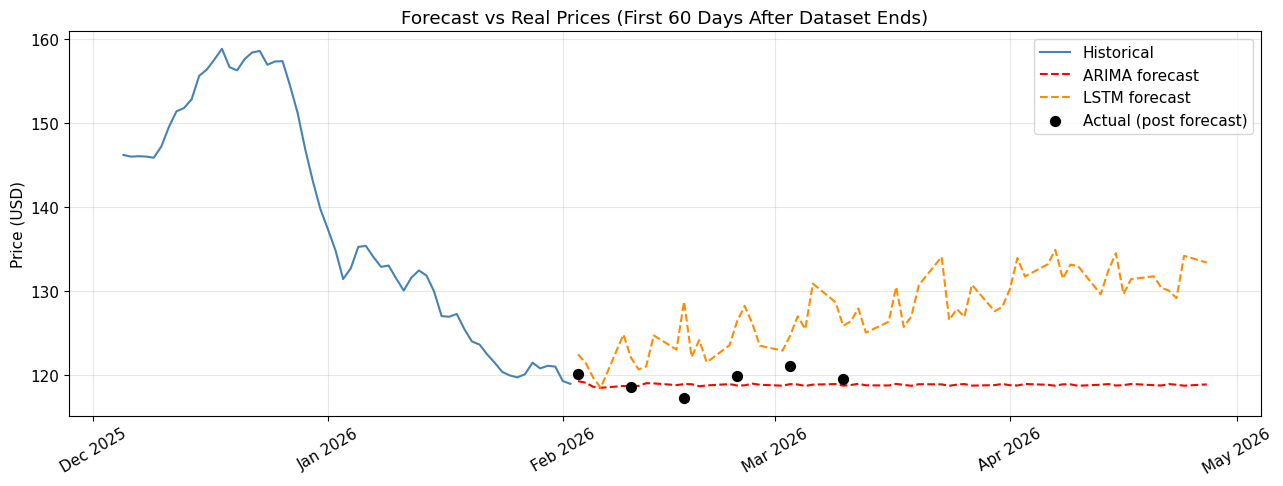

In [25]:
actual_post = {
    '2026-02-03': 120.1,
    '2026-02-10': 118.5,
    '2026-02-17': 117.2,
    '2026-02-24': 119.8,
    '2026-03-03': 121.0,
    '2026-03-10': 119.5
}

post_dates  = pd.to_datetime(list(actual_post.keys()))
post_prices = list(actual_post.values())


arima_at_post = fc_mean.reindex(post_dates, method='nearest').values
lstm_at_post  = pd.Series(lstm_fc_mean, index=future_idx).reindex(post_dates, method='nearest').values

print('Forecast vs Actual (post dataset):')
print(f'{"Date":<15} {"Actual":>10} {"ARIMA":>10} {"LSTM":>10}')
print('-' * 48)
for d, a, ar, ls in zip(post_dates, post_prices, arima_at_post, lstm_at_post):
    print(f'{str(d.date()):<15} {a:>10.2f} {ar:>10.2f} {ls:>10.2f}')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(prices.index[-60:], prices['usd'].iloc[-60:], color='steelblue', lw=1.5, label='Historical')
ax.plot(future_idx[:60], fc_mean.iloc[:60], color='red', ls='--', lw=1.5, label='ARIMA forecast')
ax.plot(future_idx[:60], lstm_fc_mean[:60], color='darkorange', ls='--', lw=1.5, label='LSTM forecast')
ax.scatter(post_dates, post_prices, color='black', zorder=5, s=50, label='Actual (post forecast)')
ax.set_title('Forecast vs Real Prices (First 60 Days After Dataset Ends)')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig13_real_vs_forecast.png', dpi=150, bbox_inches='tight')
plt.show()